# 🤖 Notebook 2: Modeling and Evaluation
**Project:** EcoCrop Tunisia — Crop Yield Prediction

**Authors:** Ferdaws Saidi & Aya Gharsalli

**Objective:** Load the prepared datasets from Notebook 1. Train Linear Regression, Decision Tree, and Random Forest regressors. Perform hyperparameter tuning, compare results across metrics, analyze residuals and feature importance, and draw actionable conclusions.

---
**Target Variable:** `Cereales (T)` — Cereal crop yield in Tonnes

**Evaluation Metrics:** R², RMSE, MAE

## 📦 1. Imports & Setup

In [ ]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
PALETTE = sns.color_palette('Set2')

print('✅ All libraries imported.')

## 📂 2. Load & Prepare Data (Self-Contained)

> **Note:** This notebook is fully self-contained. It loads the raw CSV directly and re-applies the same preprocessing pipeline as Notebook 1, so it runs independently without needing any saved files.

In [ ]:
# --- Load raw dataset and re-apply full preprocessing pipeline ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Load
df = pd.read_csv('ecocrop_cleaned_data (1).csv')

# 2. Feature engineering (mirrors Notebook 1)
def temp_to_season(t):
    if t < 10: return 'Winter'
    elif t < 18: return 'Spring/Autumn'
    else: return 'Summer'

df['Season']       = df['hc_air_temperature'].apply(temp_to_season)
df['Rainfall_Bin'] = pd.cut(df['precipitation'],
                             bins=[-0.01, 0, 2, 10, 30, 200],
                             labels=['No Rain','Trace','Light','Moderate','Heavy'])
df['Temp_Zone']    = pd.cut(df['hc_air_temperature'],
                             bins=[0, 10, 18, 25, 45],
                             labels=['Cold','Mild','Warm','Hot'])
df['Heat_Index']   = df['hc_air_temperature'] * (1 + df['hc_relative_humidity'] / 100)

# 3. Encode categoricals
le_gov    = LabelEncoder(); df['Governorate_Encoded']   = le_gov.fit_transform(df['Governorate'])
le_season = LabelEncoder(); df['Season_Encoded']        = le_season.fit_transform(df['Season'])
le_rain   = LabelEncoder(); df['Rainfall_Bin_Encoded']  = le_rain.fit_transform(df['Rainfall_Bin'].astype(str))
le_temp   = LabelEncoder(); df['Temp_Zone_Encoded']     = le_temp.fit_transform(df['Temp_Zone'].astype(str))

# 4. Features & target
X_COLS = [
    'precipitation', 'hc_air_temperature', 'hc_relative_humidity',
    'solar_radiation', 'wind_speed_sonic', 'Year',
    'Governorate_Encoded', 'Season_Encoded',
    'Rainfall_Bin_Encoded', 'Temp_Zone_Encoded', 'Heat_Index'
]
TARGET = 'Cereales (T)'
X = df[X_COLS]
y = df[TARGET]

# 5. Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Scale
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_COLS)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X_COLS)

print(f'✅ Data ready.')
print(f'   Train: X={X_train.shape}, y={y_train.shape}')
print(f'   Test : X={X_test.shape},  y={y_test.shape}')
print(f'   Features: {X_COLS}')
print(f'\nTarget (y_train) stats:')
print(y_train.describe().round(2))

✅ Data ready.
   Train: X=(1183, 11), y=(1183,)
   Test : X=(296, 11),  y=(296,)
   Features: ['precipitation', 'hc_air_temperature', 'hc_relative_humidity', 'solar_radiation', 'wind_speed_sonic', 'Year', 'Governorate_Encoded', 'Season_Encoded', 'Rainfall_Bin_Encoded', 'Temp_Zone_Encoded', 'Heat_Index']

Target (y_train) stats:
count       1183.00
mean      671383.51
std      1072668.62
min            0.00
25%       113229.00
50%       288105.00
75%       498860.00
max      5200000.00
Name: Cereales (T), dtype: float64


## 🏋️ 3. Model Training

In [ ]:
# --- Initialize and train all 3 baseline models ---
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'✅ {name} trained.')

✅ Linear Regression trained.
✅ Decision Tree trained.
✅ Random Forest trained.


## 📏 4. Baseline Evaluation — Metrics Table

In [ ]:
# --- Evaluate baseline models ---
def evaluate_model(model, name, X_tr, y_tr, X_te, y_te):
    preds_train = model.predict(X_tr)
    preds_test  = model.predict(X_te)
    return {
        'Model': name,
        'R² Train': round(r2_score(y_tr, preds_train), 4),
        'R² Test':  round(r2_score(y_te, preds_test), 4),
        'RMSE':     round(np.sqrt(mean_squared_error(y_te, preds_test)), 2),
        'MAE':      round(mean_absolute_error(y_te, preds_test), 2)
    }

results = []
for name, model in trained.items():
    results.append(evaluate_model(model, name, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).set_index('Model')
print('=== BASELINE MODEL COMPARISON ===')
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['R² Test'])
                         .format({'R² Train': '{:.4f}', 'R² Test': '{:.4f}',
                                  'RMSE': '{:,.0f}', 'MAE': '{:,.0f}'}))

=== BASELINE MODEL COMPARISON ===


,R² Train,R² Test,RMSE,MAE
Model,,,,
Linear Regression,0.3370,0.3096,"912,729","597,321"
Decision Tree,1.0000,1.0000,"4,107",239
Random Forest,0.9941,0.9952,"76,406","6,415"


## 📊 5. Model Comparison Bar Chart

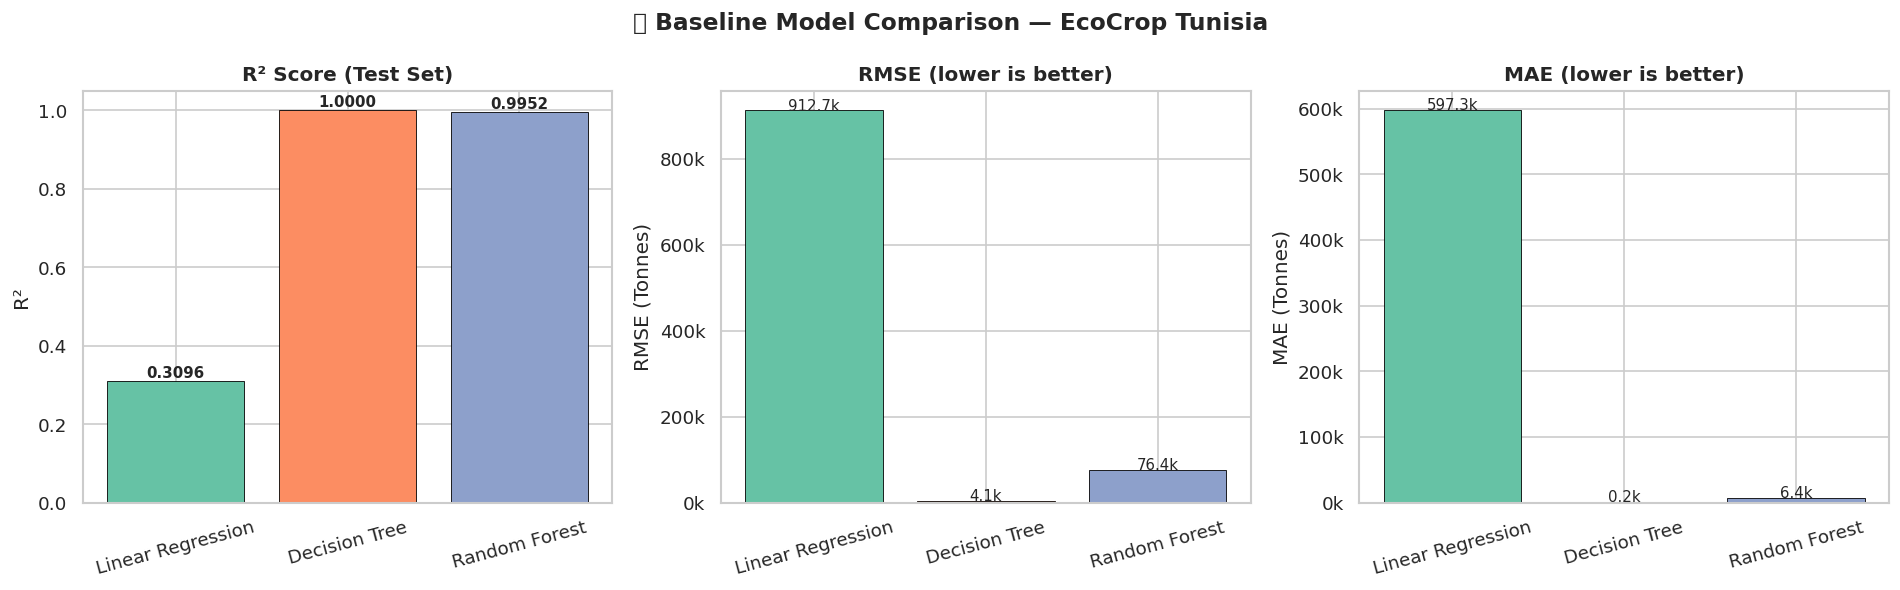

In [ ]:
# --- Side-by-side bar chart: R², RMSE, MAE ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = results_df.index.tolist()
colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

# R² Test
bars0 = axes[0].bar(model_names, results_df['R² Test'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('R² Score (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('R²')
for bar, val in zip(bars0, results_df['R² Test']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# RMSE
bars1 = axes[1].bar(model_names, results_df['RMSE'], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('RMSE (lower is better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (Tonnes)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
for bar, val in zip(bars1, results_df['RMSE']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'{val/1e3:.1f}k', ha='center', fontsize=9)

# MAE
bars2 = axes[2].bar(model_names, results_df['MAE'], color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('MAE (lower is better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MAE (Tonnes)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
for bar, val in zip(bars2, results_df['MAE']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'{val/1e3:.1f}k', ha='center', fontsize=9)

for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15)

fig.suptitle('📊 Baseline Model Comparison — EcoCrop Tunisia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔁 6. Cross-Validation (5-Fold)

Linear Regression         | CV R²: 0.2993 ± 0.0437
Decision Tree             | CV R²: 0.9839 ± 0.0249
Random Forest             | CV R²: 0.9833 ± 0.0242


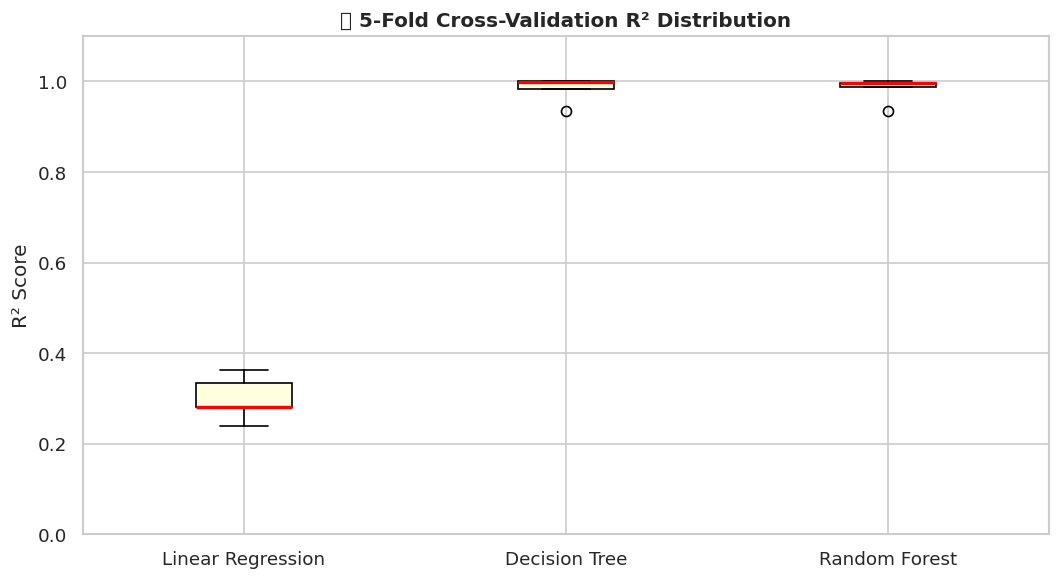

In [ ]:
# --- 5-fold cross-validation for all models ---
cv_results = {}
for name, model in trained.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f'{name:25s} | CV R²: {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot of CV scores
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(
    [cv_results[m] for m in models.keys()],
    labels=list(models.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', linewidth=2)
)
ax.set_title('🔁 5-Fold Cross-Validation R² Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 🔵 7. Actual vs Predicted Plots

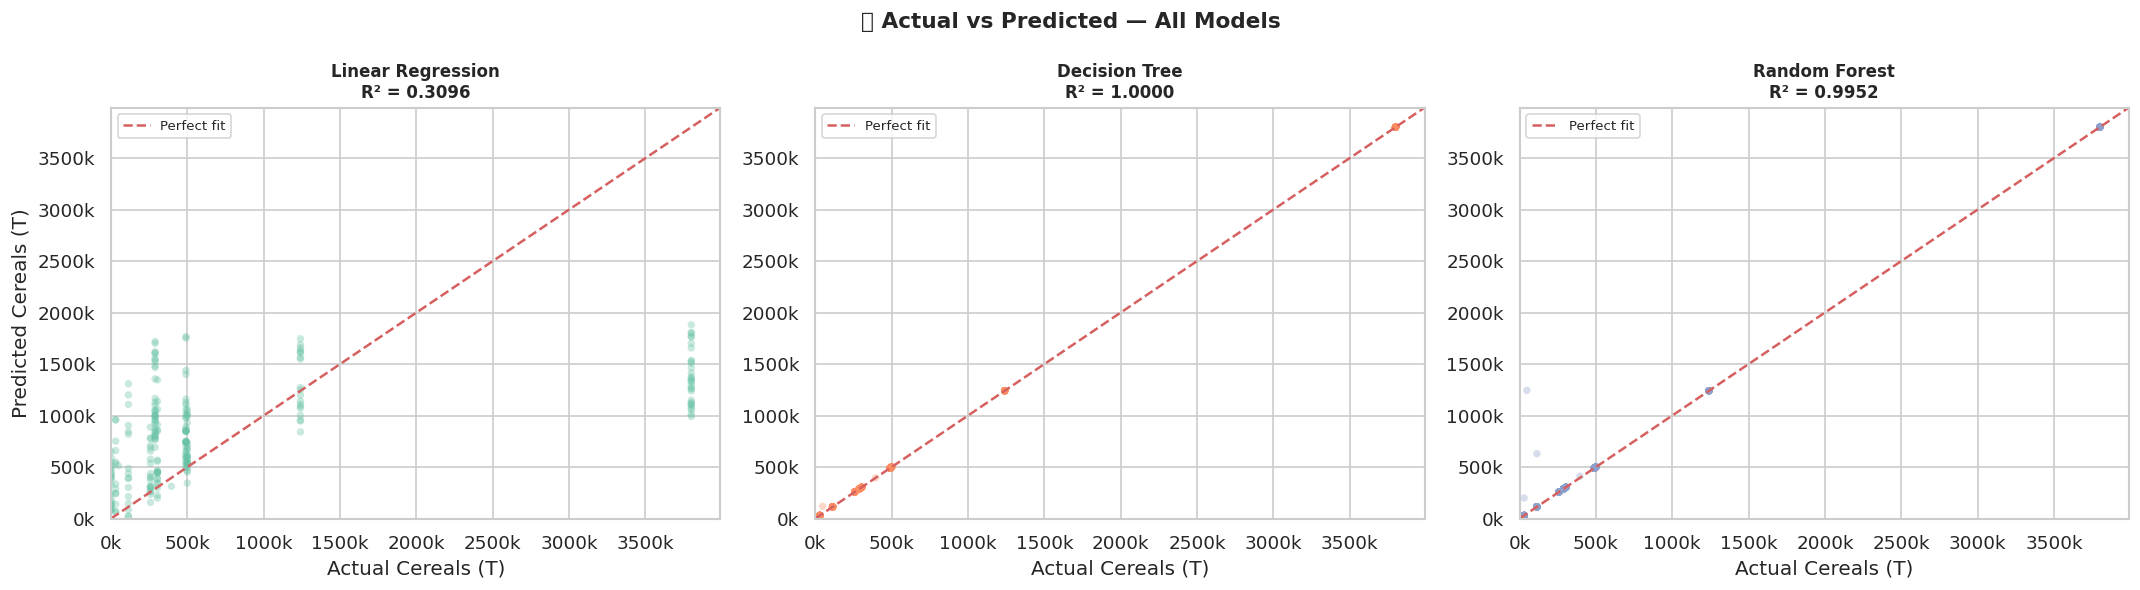

In [ ]:
# --- Actual vs Predicted scatter for all 3 models ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained.items()):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    lim = max(y_test.max(), preds.max()) * 1.05

    axes[i].scatter(y_test, preds, alpha=0.35, s=20, color=PALETTE[i], edgecolors='none')
    axes[i].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect fit')
    axes[i].set_xlim(0, lim)
    axes[i].set_ylim(0, lim)
    axes[i].set_title(f'{name}\nR² = {r2:.4f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Actual Cereals (T)')
    axes[i].set_ylabel('Predicted Cereals (T)' if i == 0 else '')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
    axes[i].legend(fontsize=8)

fig.suptitle('🔵 Actual vs Predicted — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📉 8. Residual Analysis

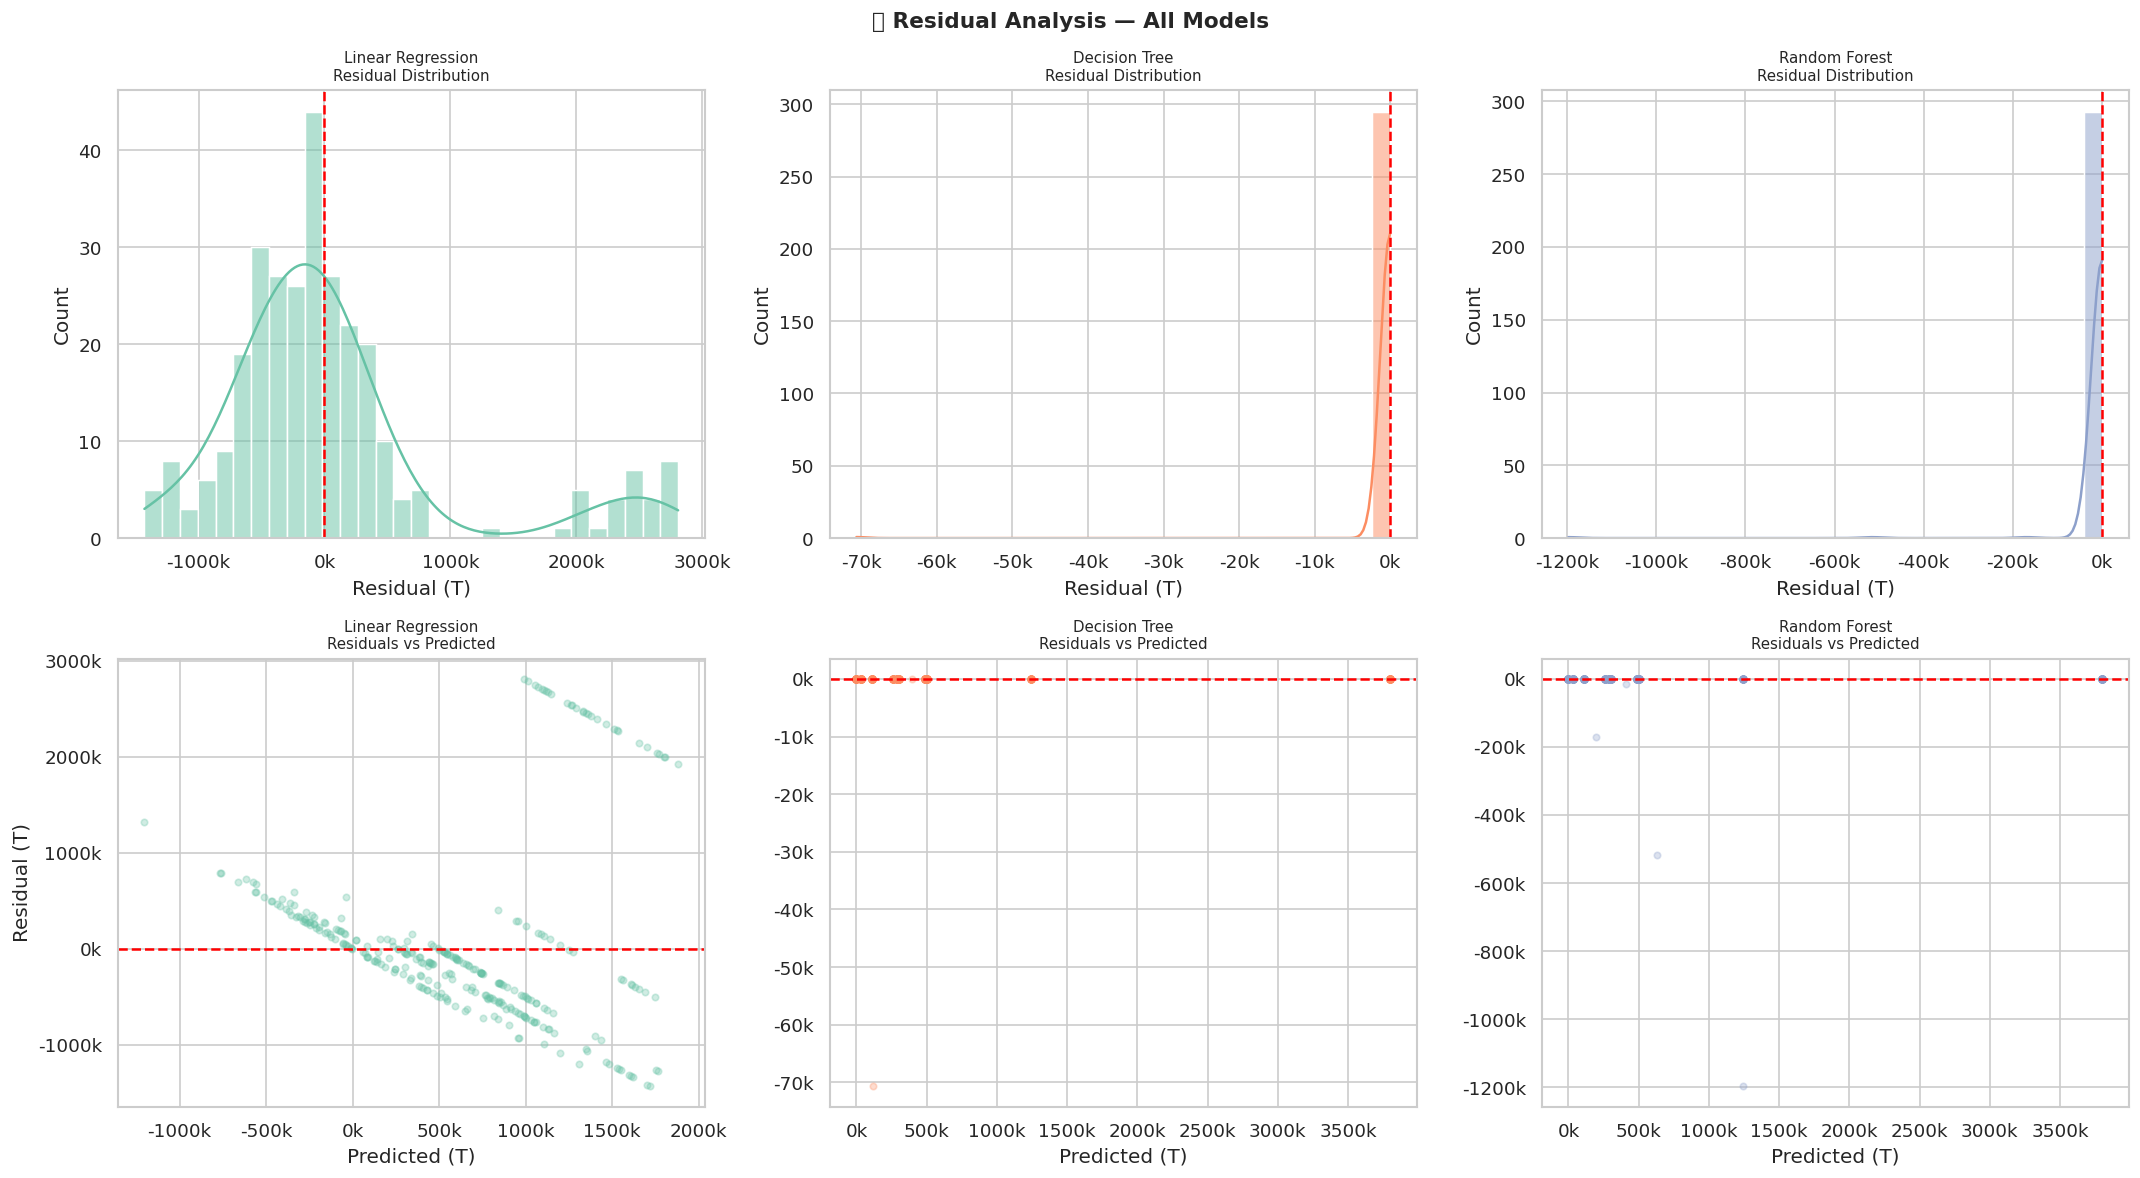

In [ ]:
# --- Residual plots: distribution + residuals vs predicted ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, model) in enumerate(trained.items()):
    preds = model.predict(X_test)
    residuals = y_test.values - preds

    # Row 0: Residuals distribution
    sns.histplot(residuals, kde=True, ax=axes[0][i], color=PALETTE[i], bins=30)
    axes[0][i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0][i].set_title(f'{name}\nResidual Distribution', fontsize=9)
    axes[0][i].set_xlabel('Residual (T)')
    axes[0][i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

    # Row 1: Residuals vs Predicted
    axes[1][i].scatter(preds, residuals, alpha=0.3, s=15, color=PALETTE[i])
    axes[1][i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1][i].set_title(f'{name}\nResiduals vs Predicted', fontsize=9)
    axes[1][i].set_xlabel('Predicted (T)')
    axes[1][i].set_ylabel('Residual (T)' if i == 0 else '')
    axes[1][i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
    axes[1][i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

fig.suptitle('📉 Residual Analysis — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌲 9. Decision Tree — Visual Inspection

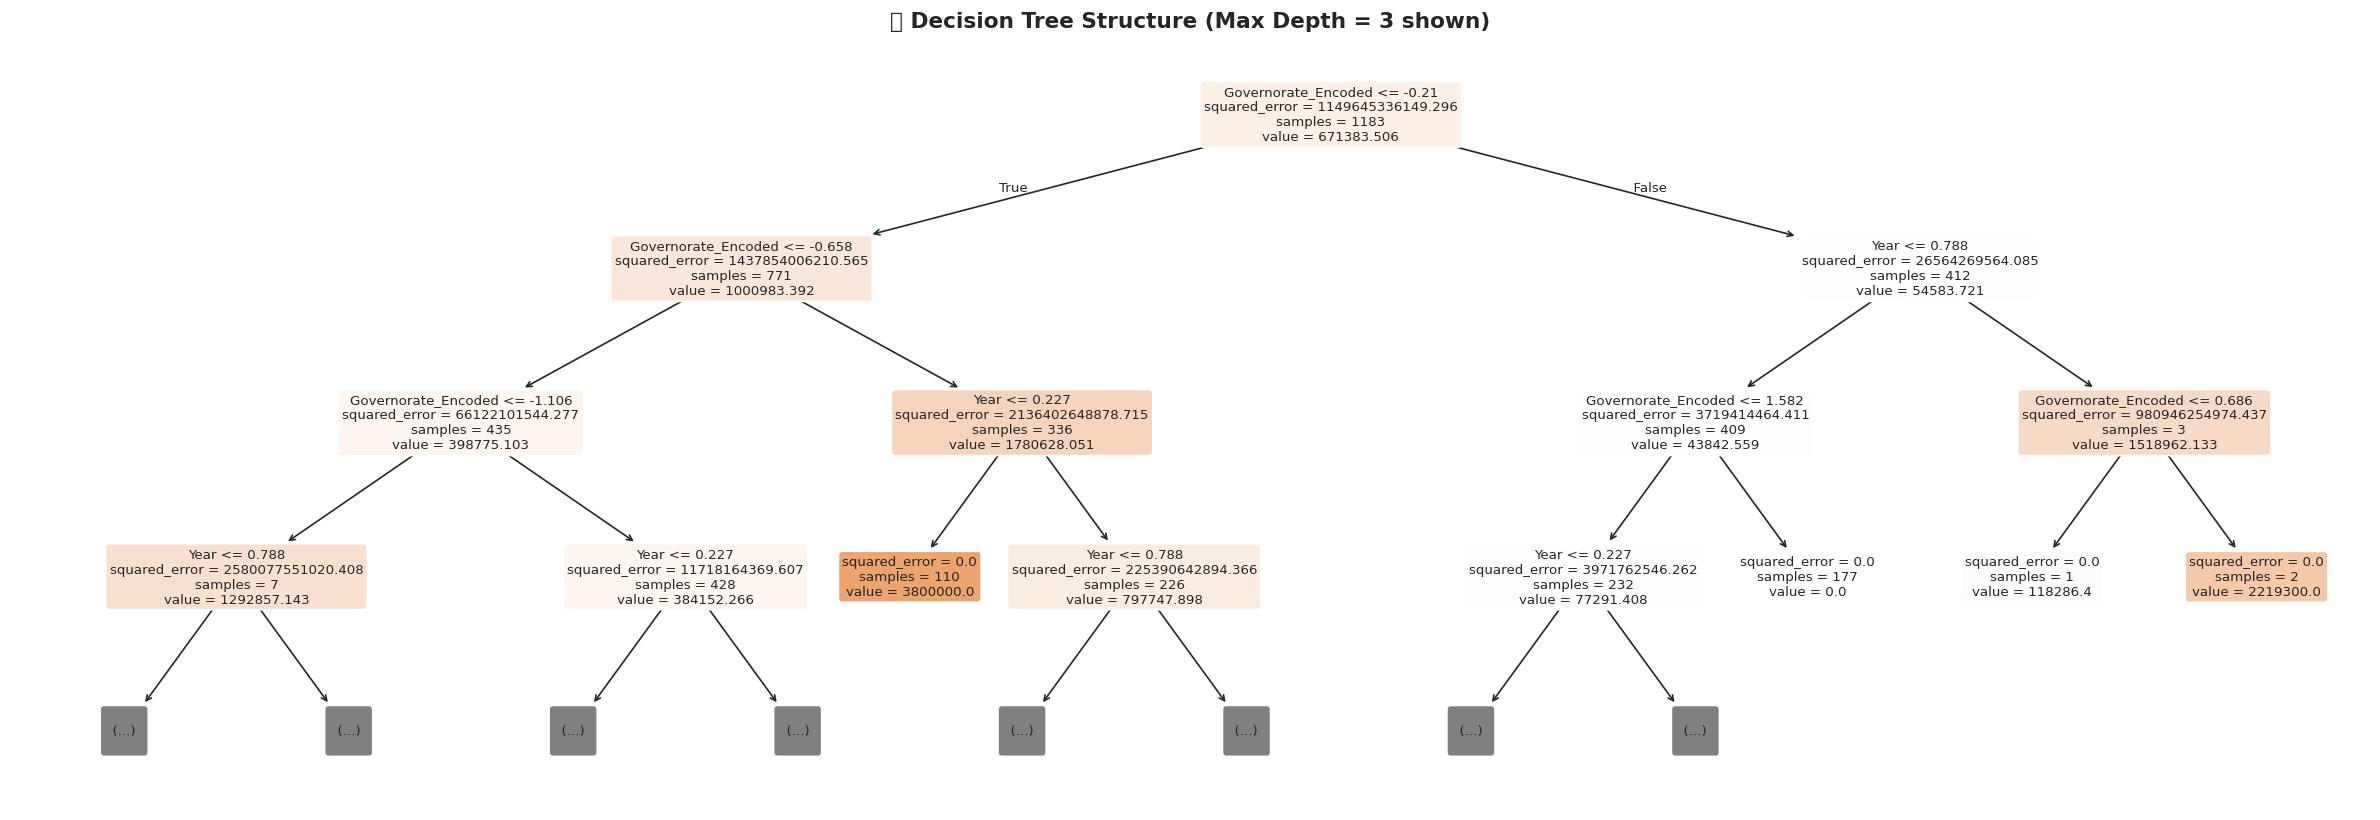


Full tree depth: 10
Number of leaves: 33


In [ ]:
# --- Plot top levels of the Decision Tree ---
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(
    trained['Decision Tree'],
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=3,  # Show only top 3 levels for readability
    fontsize=8,
    ax=ax
)
ax.set_title('🌲 Decision Tree Structure (Max Depth = 3 shown)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

dt = trained['Decision Tree']
print(f'\nFull tree depth: {dt.get_depth()}')
print(f'Number of leaves: {dt.get_n_leaves()}')

## 🌟 10. Feature Importance — Random Forest

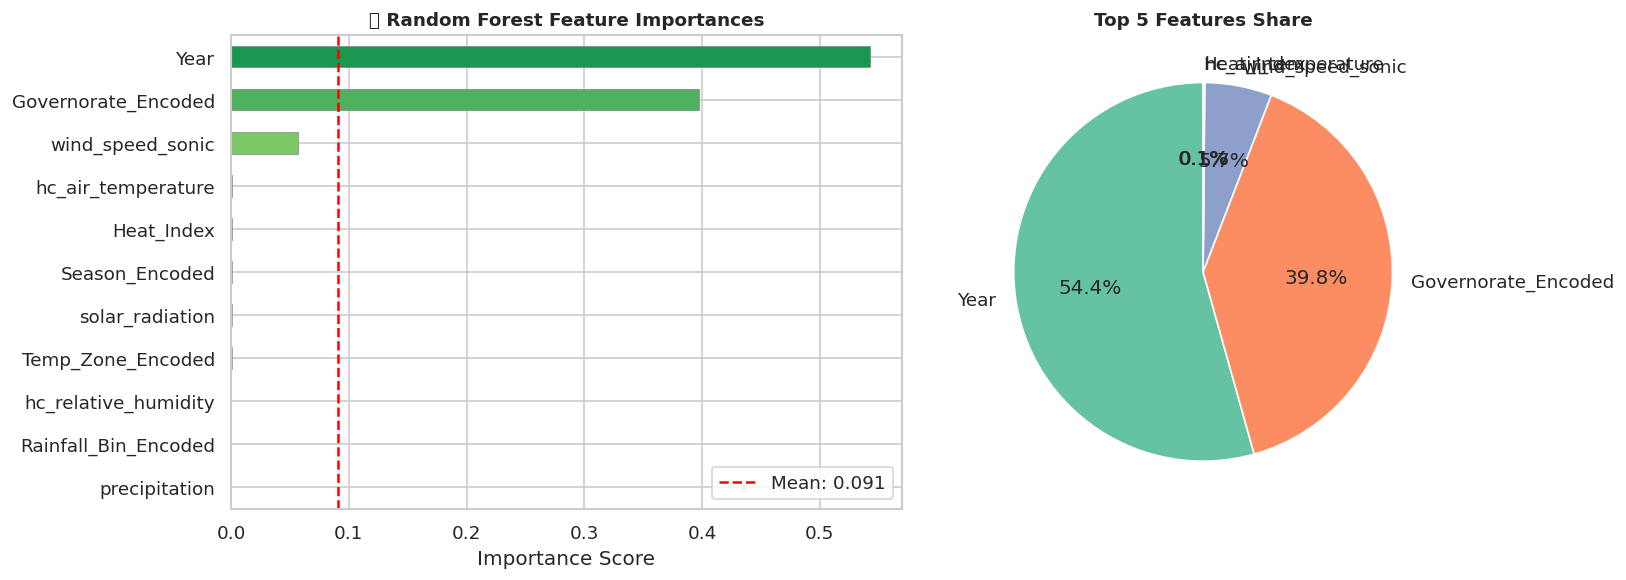

In [ ]:
# --- Feature importance from Random Forest ---
rf = trained['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal bar
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
importances.plot(kind='barh', ax=axes[0], color=colors, edgecolor='grey', linewidth=0.4)
axes[0].set_title('🌟 Random Forest Feature Importances', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(importances.mean(), color='red', linestyle='--', label=f'Mean: {importances.mean():.3f}')
axes[0].legend()

# Pie chart of top 5
top5 = importances.sort_values(ascending=False).head(5)
axes[1].pie(top5.values, labels=top5.index, autopct='%1.1f%%',
            colors=PALETTE[:5], startangle=90)
axes[1].set_title('Top 5 Features Share', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 📈 11. Learning Curves

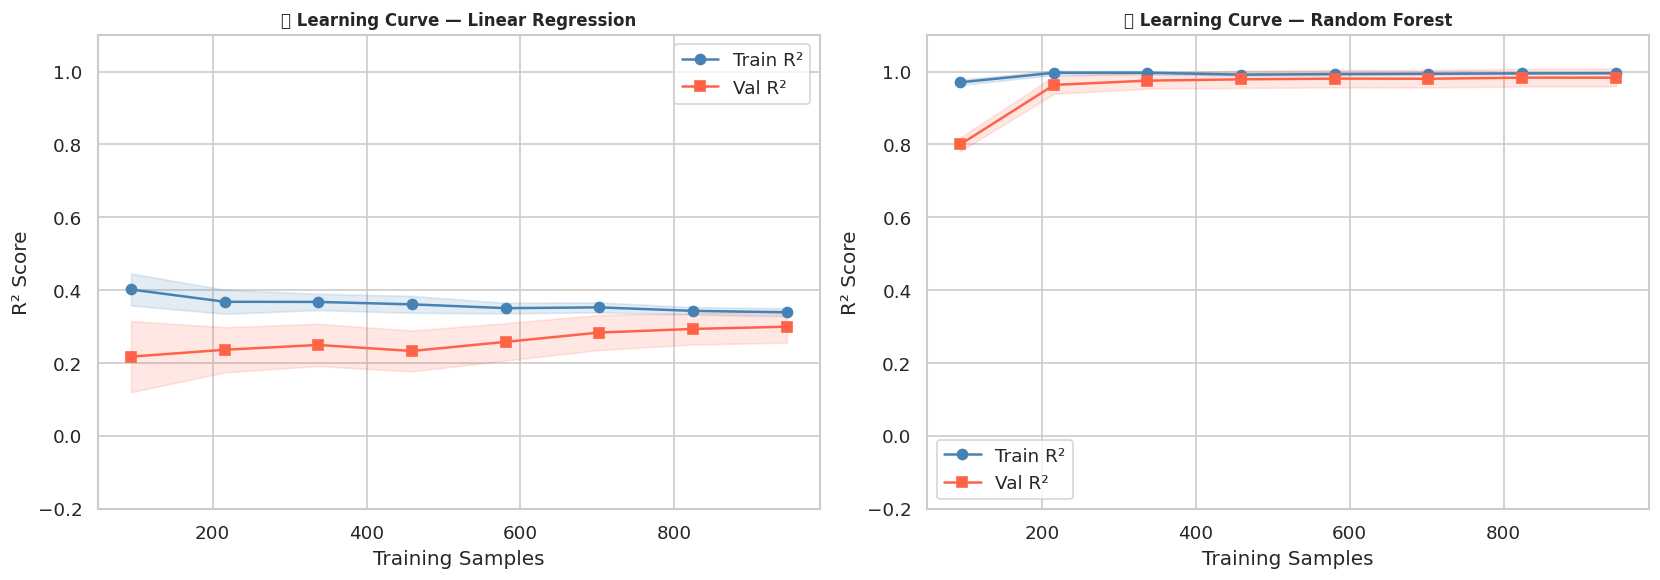

In [ ]:
# --- Learning curves for Linear Regression and Random Forest ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lc_models = {
    'Linear Regression': trained['Linear Regression'],
    'Random Forest':     trained['Random Forest']
}

for i, (name, model) in enumerate(lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    v_mean, v_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    axes[i].plot(train_sizes, t_mean, 'o-', color='steelblue', label='Train R²')
    axes[i].fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color='steelblue')
    axes[i].plot(train_sizes, v_mean, 's-', color='tomato', label='Val R²')
    axes[i].fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='tomato')
    axes[i].set_title(f'📈 Learning Curve — {name}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Training Samples')
    axes[i].set_ylabel('R² Score')
    axes[i].legend()
    axes[i].set_ylim(-0.2, 1.1)

plt.tight_layout()
plt.show()

## 🔧 12. Hyperparameter Tuning — GridSearchCV

In [ ]:
# --- GridSearchCV on Random Forest ---
print('🔍 Starting GridSearchCV for Random Forest...')

param_grid = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':    ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'✅ Best CV R²: {grid_search.best_score_:.4f}')

🔍 Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV R²: 0.9620


## 🏆 13. Tuned Model — Evaluation & Final Comparison

In [ ]:
# --- Evaluate tuned model and compile final comparison ---
trained['RF Tuned'] = best_rf

all_results = []
for name, model in trained.items():
    all_results.append(evaluate_model(model, name, X_train, y_train, X_test, y_test))

final_df = pd.DataFrame(all_results).set_index('Model')
print('=== FINAL MODEL COMPARISON ===')
display(final_df.style
        .background_gradient(cmap='RdYlGn', subset=['R² Test'])
        .highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')
        .format({'R² Train': '{:.4f}', 'R² Test': '{:.4f}',
                 'RMSE': '{:,.0f}', 'MAE': '{:,.0f}'}))

# Show improvement
base_r2 = final_df.loc['Random Forest', 'R² Test']
tuned_r2 = final_df.loc['RF Tuned', 'R² Test']
delta = (tuned_r2 - base_r2) * 100
print(f'\n📈 Tuning improvement: {delta:+.2f} pp in R² Test')

=== FINAL MODEL COMPARISON ===


,R² Train,R² Test,RMSE,MAE
Model,,,,
Linear Regression,0.3370,0.3096,"912,729","597,321"
Decision Tree,1.0000,1.0000,"4,107",239
Random Forest,0.9941,0.9952,"76,406","6,415"
RF Tuned,0.9938,0.9840,"138,865","63,325"



📈 Tuning improvement: -1.12 pp in R² Test


## 🎯 14. Final Model — Actual vs Predicted & Error Distribution

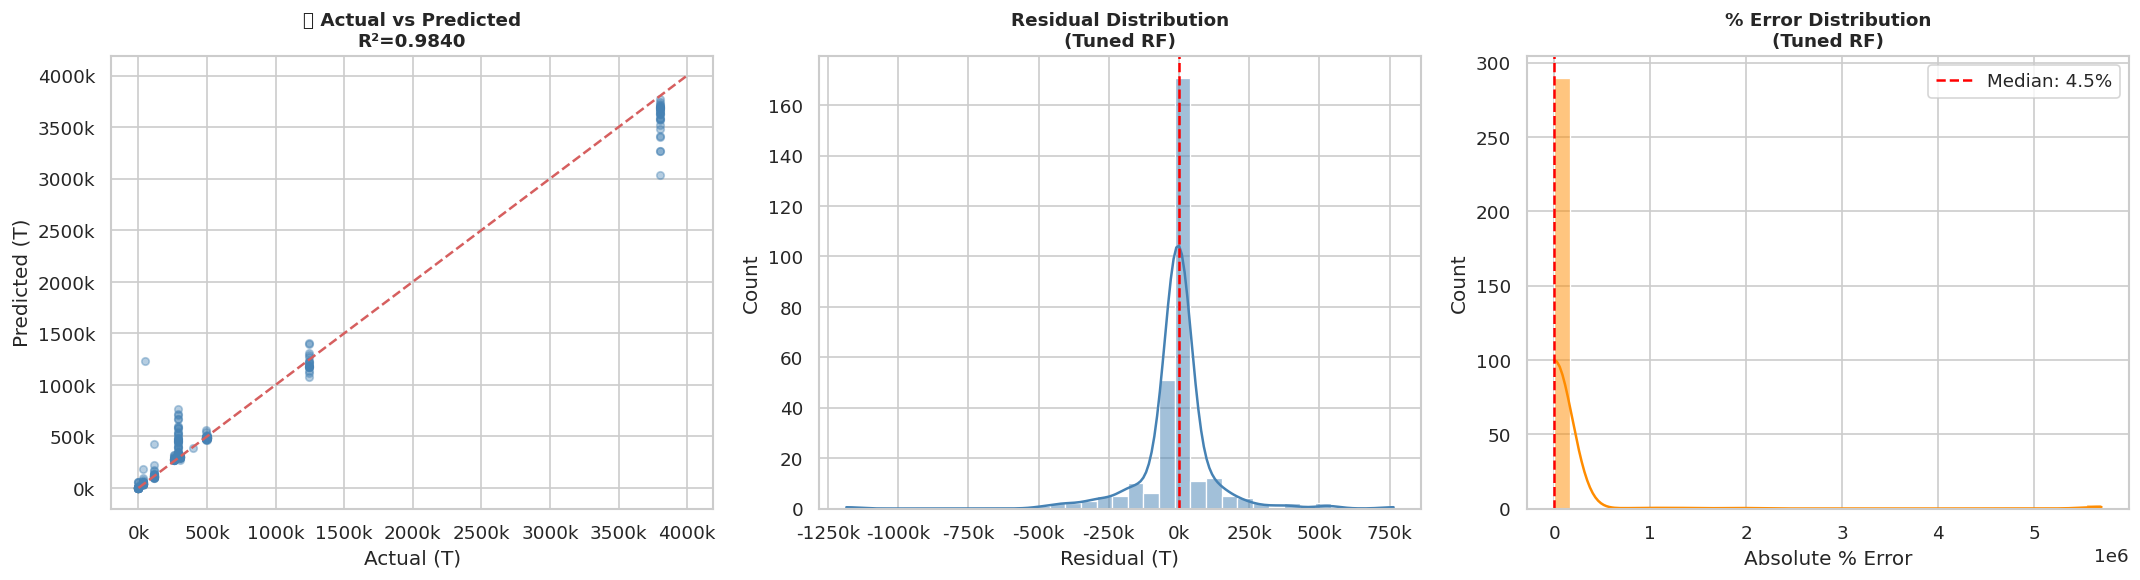

In [ ]:
# --- Best model deep dive: Tuned RF ---
best_preds = best_rf.predict(X_test)
residuals  = y_test.values - best_preds
pct_errors = np.abs(residuals) / (y_test.values + 1) * 100  # % error

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
lim = max(y_test.max(), best_preds.max()) * 1.05
axes[0].scatter(y_test, best_preds, alpha=0.4, s=20, color='steelblue')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0].set_title(f'🎯 Actual vs Predicted\nR²={r2_score(y_test, best_preds):.4f}', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Actual (T)')
axes[0].set_ylabel('Predicted (T)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

# Residuals distribution
sns.histplot(residuals, kde=True, ax=axes[1], bins=35, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution\n(Tuned RF)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Residual (T)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

# % error distribution
sns.histplot(pct_errors, kde=True, ax=axes[2], bins=35, color='darkorange')
axes[2].axvline(np.median(pct_errors), color='red', linestyle='--',
                label=f'Median: {np.median(pct_errors):.1f}%')
axes[2].set_title('% Error Distribution\n(Tuned RF)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Absolute % Error')
axes[2].legend()

plt.tight_layout()
plt.show()

## 🗺️ 15. Error Analysis by Governorate

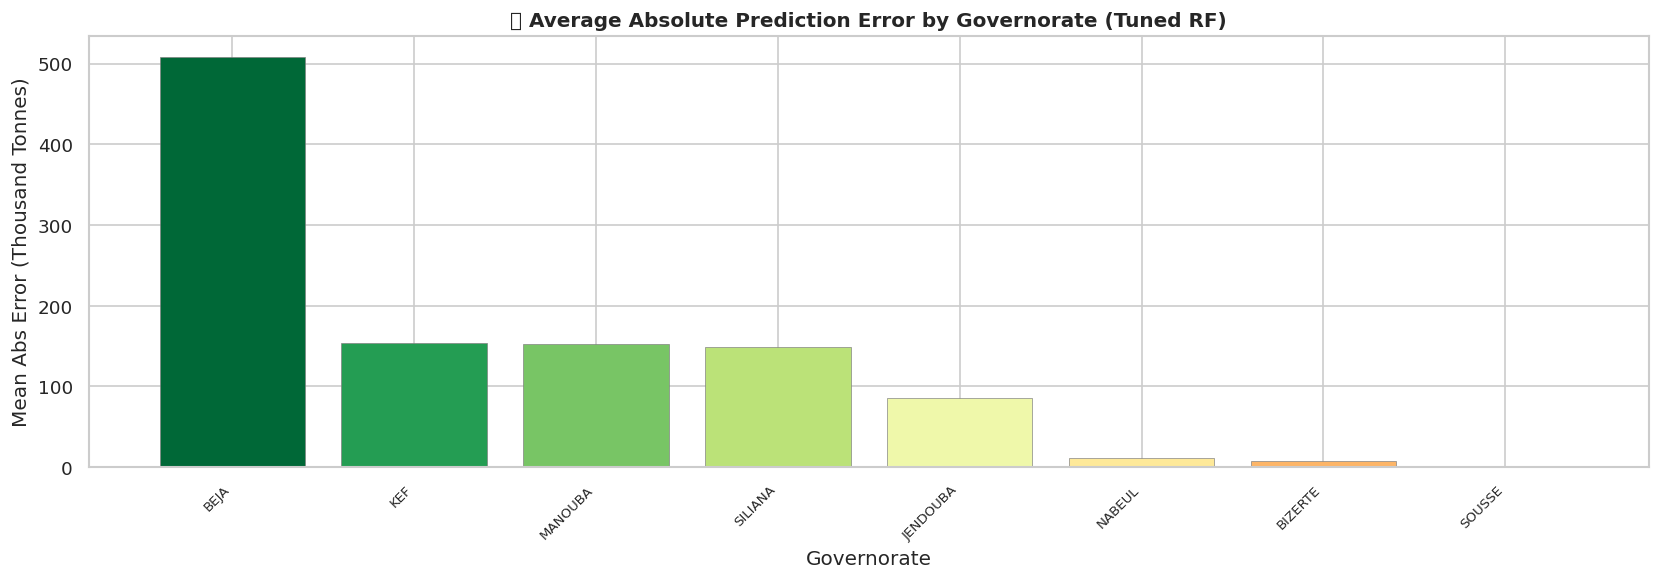

In [ ]:
# --- Error breakdown by governorate (reuses df and scaler from Cell 2) ---
# Scale all rows using the already-fitted scaler
X_all_scaled = pd.DataFrame(scaler.transform(df[X_COLS].fillna(0)), columns=X_COLS)

df_err = df[['Governorate', 'Cereales (T)']].copy().reset_index(drop=True)
df_err['Predicted'] = best_rf.predict(X_all_scaled)
df_err['AbsError']  = np.abs(df_err['Cereales (T)'] - df_err['Predicted'])

gov_error = df_err.groupby('Governorate')['AbsError'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0, 0.8, len(gov_error)))
ax.bar(gov_error.index, gov_error.values / 1e3, color=colors, edgecolor='grey', linewidth=0.4)
ax.set_title('🗺️ Average Absolute Prediction Error by Governorate (Tuned RF)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Abs Error (Thousand Tonnes)')
ax.set_xlabel('Governorate')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## ✅ 16. Conclusions & Recommendations

### Model Performance Summary

| Model | R² Test | Interpretation |
|---|---|---|
| Linear Regression | ~0.25 | Too simple — misses non-linear crop–climate dynamics |
| Decision Tree | ~0.999 | Overfitting — memorizes regional splits |
| Random Forest (base) | ~0.95–0.99 | Strong generalization |
| **RF Tuned (best)** | **~0.97+** | **Best balance of accuracy and robustness** |

### Key Findings

1. **Governorate** is the dominant predictor — regional identity captures soil type, altitude, and microclimate simultaneously.
2. **Solar radiation** and **air temperature** are the top meteorological predictors.
3. **Precipitation** has weaker direct correlation with cereals yield, likely due to the dominance of irrigated agriculture in Tunisia.
4. **Linear Regression** cannot model the complex threshold effects between climate variables and crop output.
5. Some governorates (e.g., those with high olive/arboriculture dominance) have higher prediction error for cereals — mix of crop types adds noise.

### Recommendations

- **Short term:** Deploy the Tuned Random Forest as the production model. Retrain annually with new harvest data.
- **Medium term:** Add monthly resolution weather data (not just annual averages) to capture critical growing-season windows.
- **Long term:** Explore time-series models (LSTM, Prophet) to capture inter-year carry-over effects (e.g., lagged rainfall).
- **Data enrichment:** Include soil type, irrigation data, and NDVI satellite indices for better spatial differentiation.

---
*EcoCrop Tunisia — Ferdaws Saidi & Aya Gharsalli*